#  음용수 적합성 검증 
    - 문제 정의 : ph, Hardness , Solids , Chloramines , Sulfate , Conductivity , Organic_carbon , Trihalomethanes , Turbidity 등의 수질 지표를 통해 음용수로 적합한지 판단
### 필수 포함 내용 
    - 상데 EDA 시각화 결과 
    - 평가 지표 수치 출력
    - 실제값 대비 예측 결과 시각화 ( 산점도 / 혼동행렬 / ROC (선택사항) )
    - input으로 입력 받아 결과 출력

In [41]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [42]:
# 데이터 분석 
import pandas as pd
import numpy as np

# 데이터 시각화 분석 라이브러리 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드

In [43]:
df = pd.read_csv('./data/water_potability.csv' , index_col = False , encoding = "utf-8-sig")

In [44]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


#### 데이터 구조 확인

In [45]:
df.shape

(3276, 10)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [47]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Potability 클래스 분포 countplot 확인

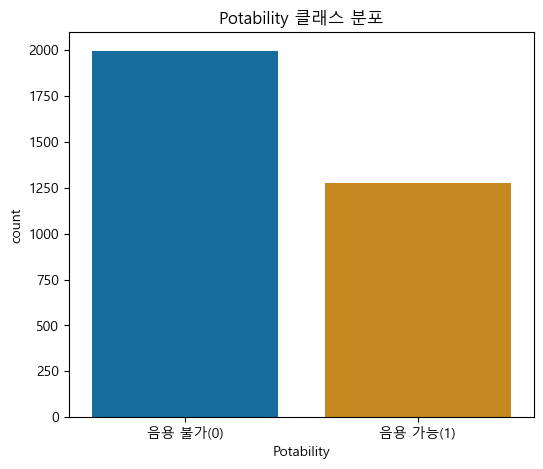

In [48]:
plt.figure(figsize = (6,5))

x_label = df['Potability'].map({
    0 : '음용 불가(0)',
    1 : '음용 가능(1)'
})
sns.countplot(data = df , x = x_label,hue= x_label,palette = 'colorblind',legend=False)
plt.title('Potability 클래스 분포')
plt.show()

In [49]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

- 음용불가 : 1998개 , 음용 가능 : 1278개로 데이터간의 약한 불균형이 존재한다 .
    - accuracy만으로는 모델 평가가 정확하지 않다.
    - 모델 평가는 classification_report를 통해 Precision 과 Recall을 확인할 필요가 있다. 

#### 결측치 확인

In [50]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

ph , Sulfate , Trihalomethanes 컬럼에서 결측치가 발견되었다 .

### 중복치 

In [51]:
df.duplicated().sum()

np.int64(0)

중복치는 존재하지 않음

In [52]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

### 이상치 확인

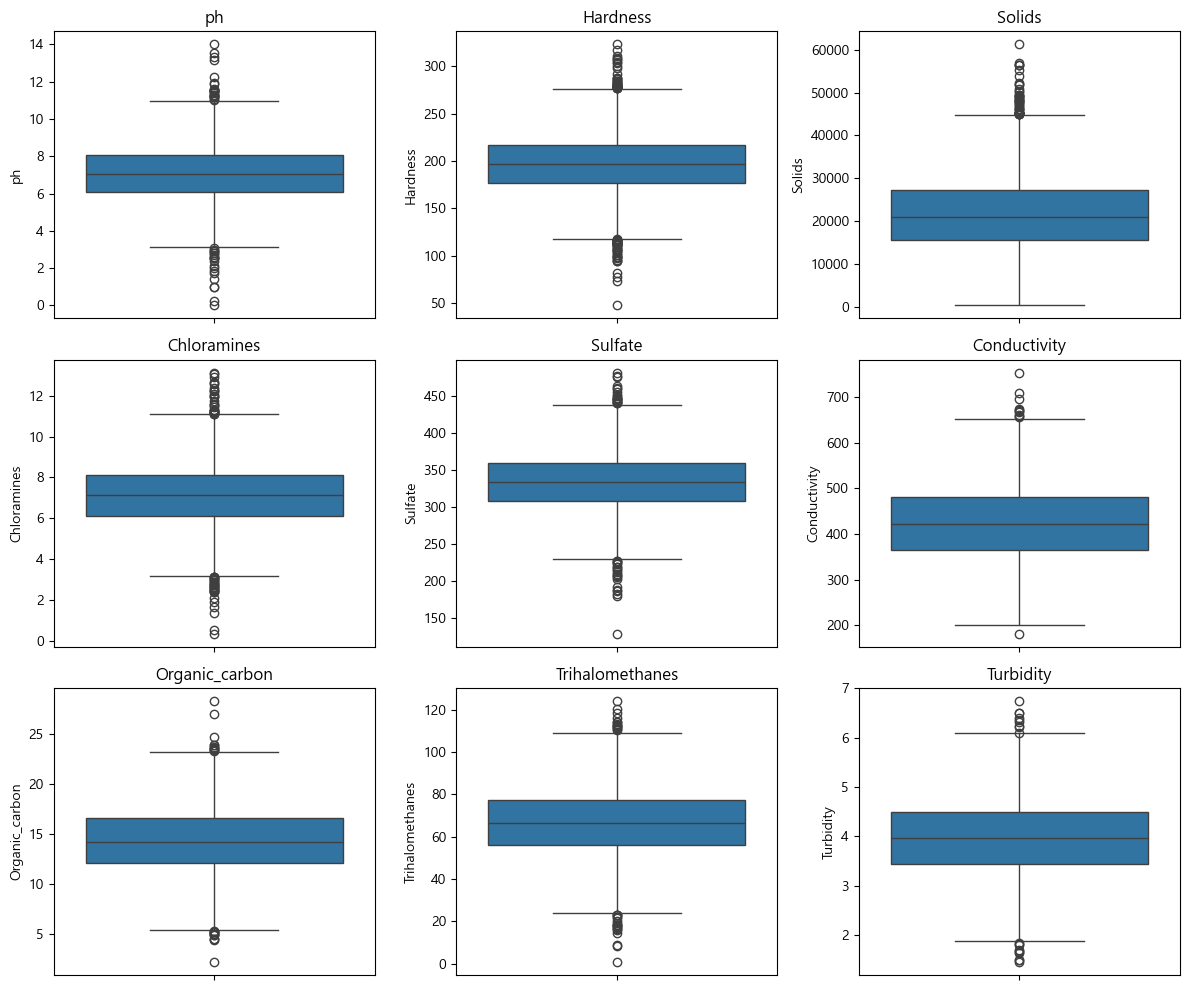

In [53]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(nrows = 3 , ncols = 3)

fig.set_size_inches(12,10)   # 전체 plot 사이즈 

ax1.set(title = 'ph')
sns.boxplot(data=df,y='ph',ax=ax1)
ax2.set(title = 'Hardness')
sns.boxplot(data=df,y='Hardness',ax=ax2)
ax3.set(title = 'Solids')
sns.boxplot(data=df,y='Solids',ax=ax3)
ax4.set(title = 'Chloramines')
sns.boxplot(data=df,y='Chloramines',ax=ax4)
ax5.set(title = 'Sulfate')
sns.boxplot(data=df,y='Sulfate',ax=ax5)
ax6.set(title = 'Conductivity')
sns.boxplot(data=df,y='Conductivity',ax=ax6)
ax7.set(title = 'Organic_carbon')
sns.boxplot(data=df,y='Organic_carbon',ax=ax7)
ax8.set(title = 'Trihalomethanes')
sns.boxplot(data=df,y='Trihalomethanes',ax=ax8)
ax9.set(title = 'Turbidity')
sns.boxplot(data=df,y='Turbidity',ax=ax9)

plt.tight_layout()
plt.show()

데이터에 이상치가 있기 때문에 평균이 아닌 중앙값으로 결측치를 대체한다.

In [54]:
df.fillna({
    'ph' : df['ph'].median(),
    'Sulfate' : df['Sulfate'].median(),
    'Trihalomethanes' : df['Trihalomethanes'].median()} , inplace = True)

In [55]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Potability별 ph,Hardness 분포 분석

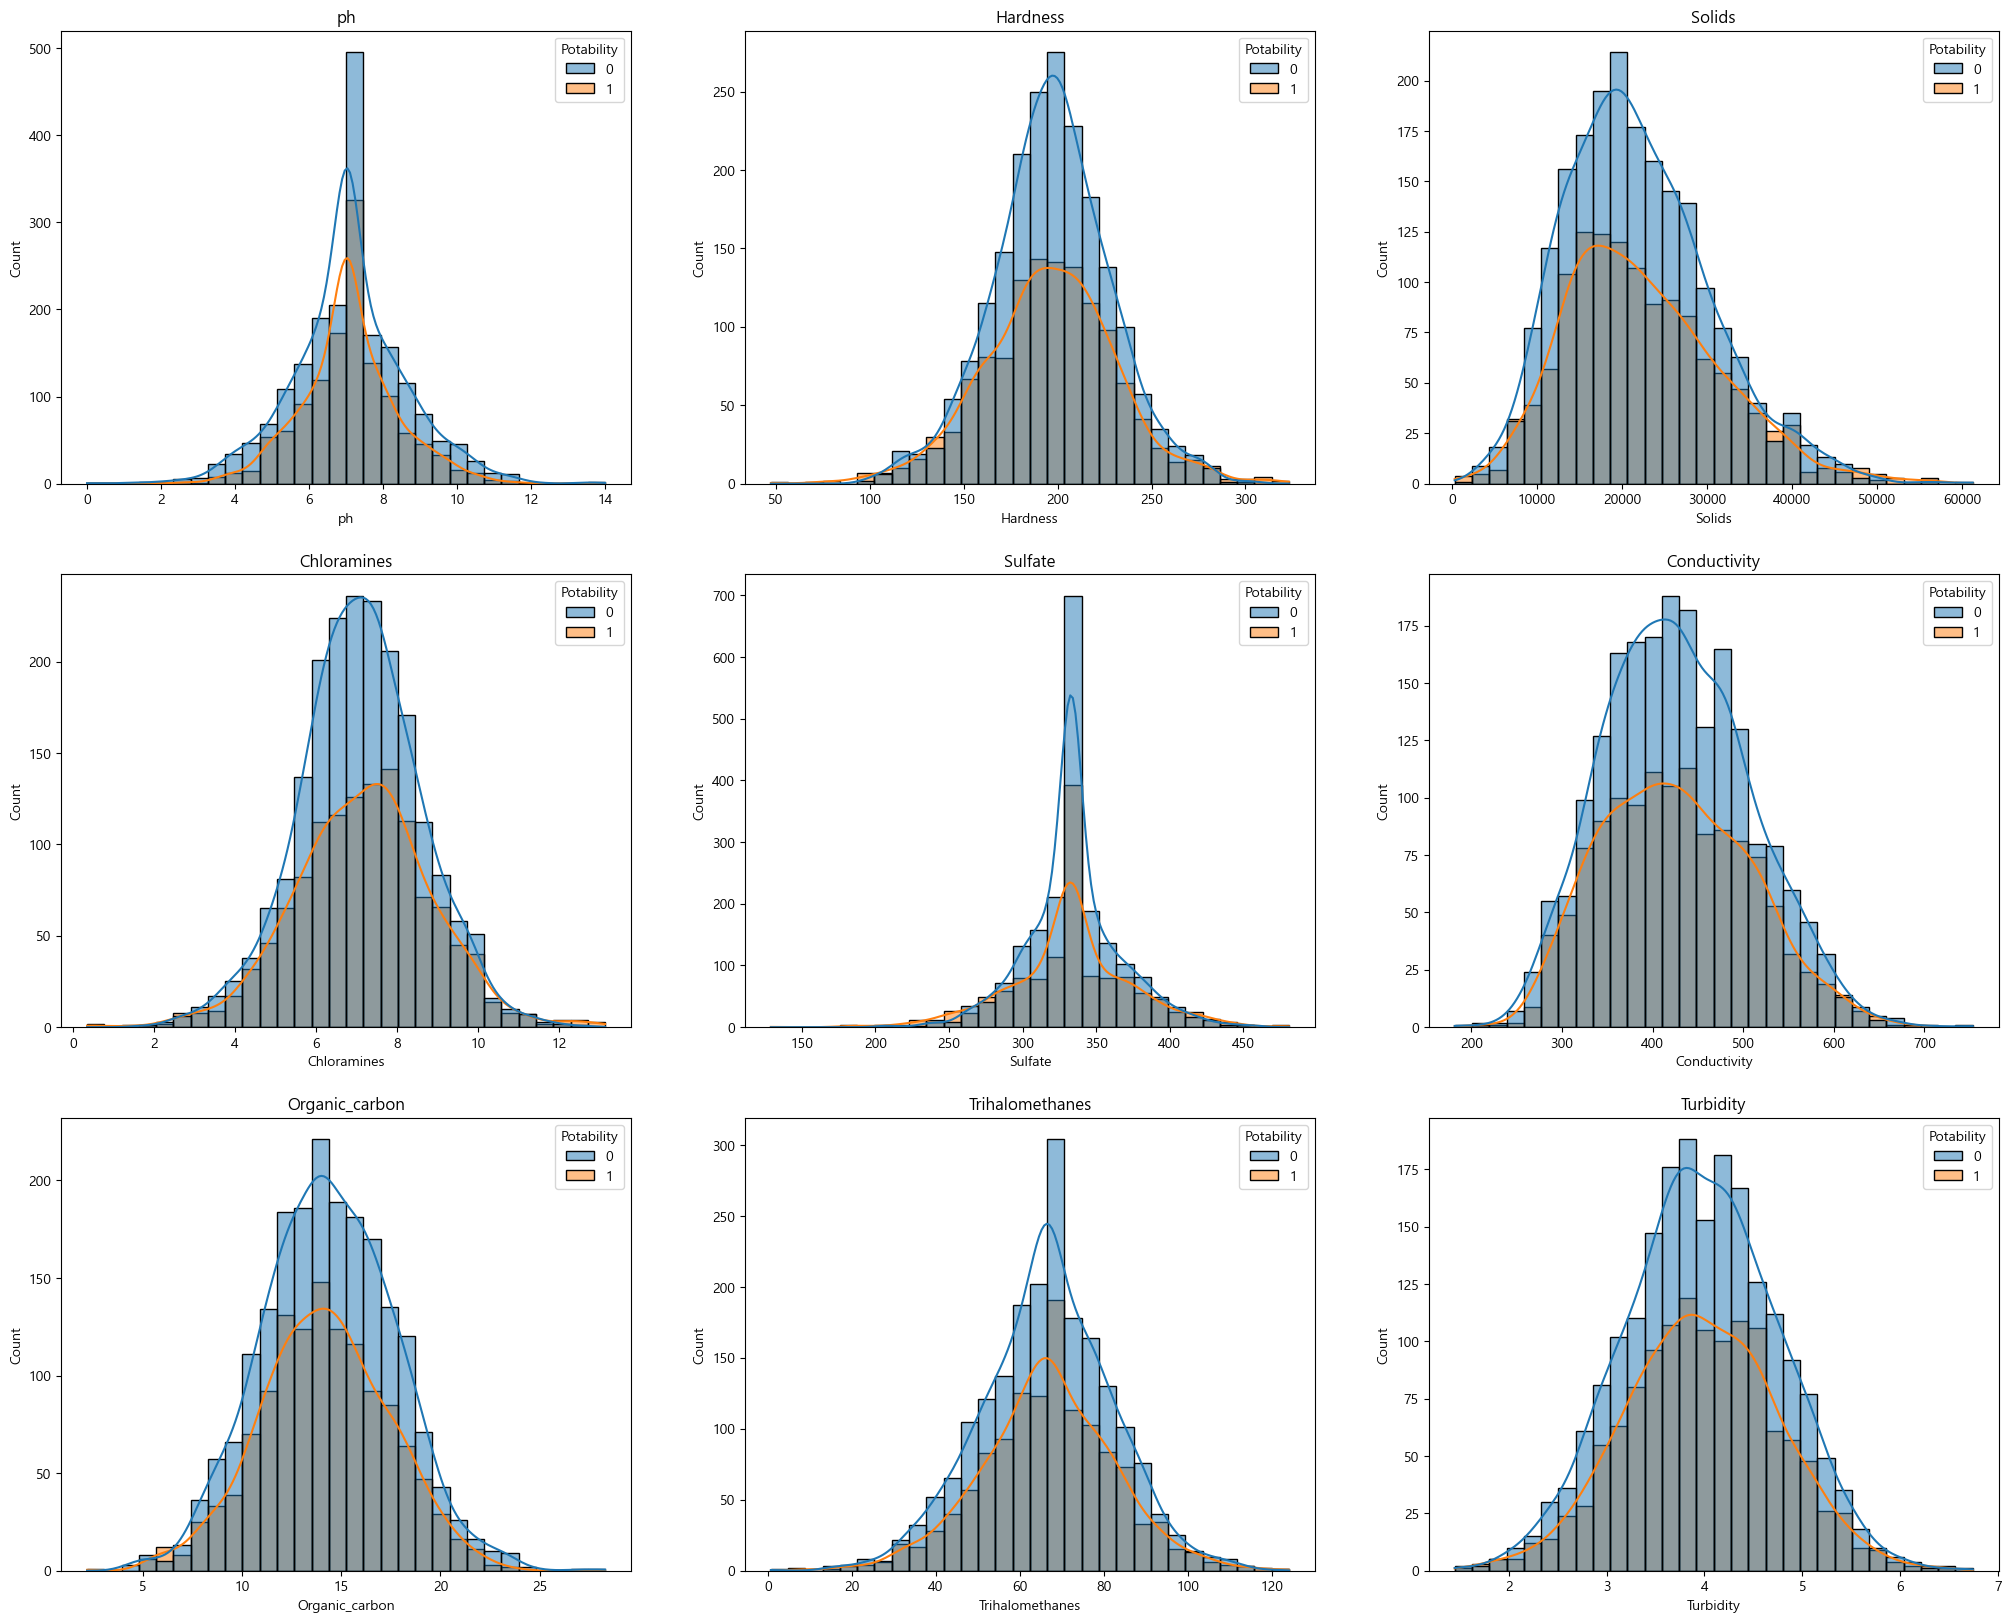

In [56]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(nrows=3,ncols=3)

fig.set_size_inches(25,20)

ax1.set(title='ph')
sns.histplot(data=df,x='ph',hue='Potability',bins=30,kde = True,ax=ax1)

ax2.set(title='Hardness')
sns.histplot(data=df,x='Hardness',hue='Potability',bins=30,kde = True,ax=ax2)

ax3.set(title='Solids')
sns.histplot(data=df,x='Solids',hue='Potability',bins=30,kde = True,ax=ax3)

ax4.set(title='Chloramines')
sns.histplot(data=df,x='Chloramines',hue='Potability',bins=30,kde = True,ax=ax4)

ax5.set(title='Sulfate')
sns.histplot(data=df,x='Sulfate',hue='Potability',bins=30,kde = True,ax=ax5)

ax6.set(title='Conductivity')
sns.histplot(data=df,x='Conductivity',hue='Potability',bins=30,kde = True,ax=ax6)

ax7.set(title='Organic_carbon')
sns.histplot(data=df,x='Organic_carbon',hue='Potability',bins=30,kde = True,ax=ax7)

ax8.set(title='Trihalomethanes')
sns.histplot(data=df,x='Trihalomethanes',hue='Potability',bins=30,kde = True,ax=ax8)

ax9.set(title='Turbidity')
sns.histplot(data=df,x='Turbidity',hue='Potability',bins=30,kde = True,ax=ax9)

plt.show()

- 각 feature 확률 밀도 함수를 보면 분포가 거의 일치한다
    - feature가 특정 값에서 음용가능/불가능으로 나뉘는 기준이 모호하다  
    - 어떤 특징이 Potability를 결정하는지 명확하게 보이는것은 없다.
    - 음용 가능 / 불가능 여부를 판단하려면 추가적인 특징 데이터가 필요할것으로 사료된다.
    - 미생물 함유 지표 , 중금속 함유 자표 등의 음용수에 관한 명확한 특징 데이터가 필요하다 .

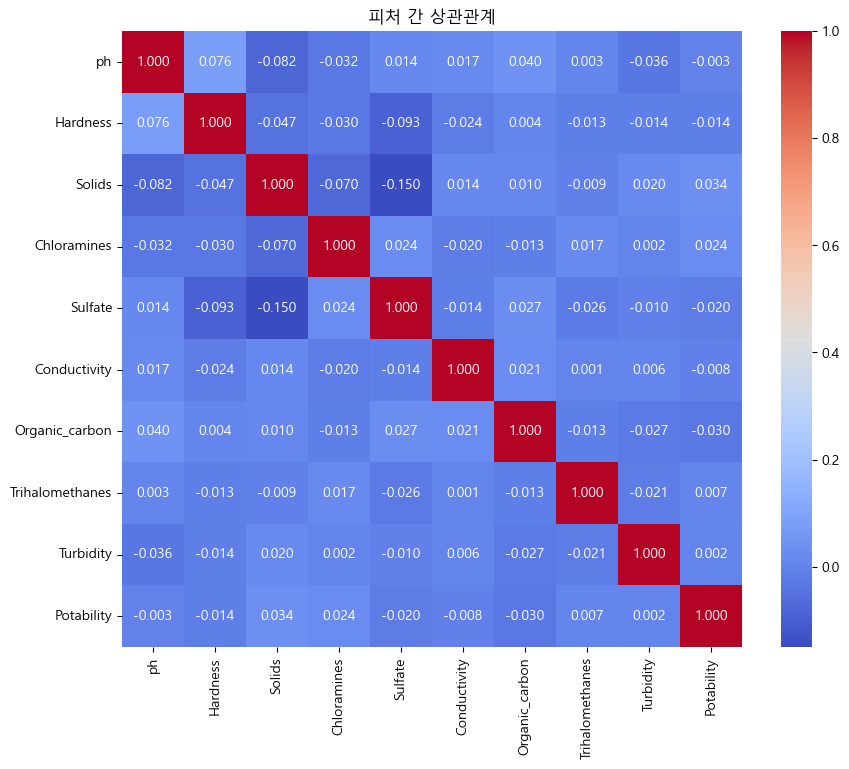

In [57]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot = True,fmt='.3f',cmap="coolwarm")
plt.title("피처 간 상관관계")
plt.show()

서로 큰 상관관계를 가지는 feature가 관측되지 않음 => 각 Feature간 상관관계가 아주 미미함 

Potability와 각 Feature간의 상관관계가 낮음 => 각 feature가 아주 미미하게 Potability에 영향을 줌  
    - 현재 데이터셋으로는 모델을 학습시킬때 전체 feature를 학습시켜야함  

독립/종속(Potability) 분리

In [58]:
X = df.drop('Potability',axis = 1)
y = df['Potability']

In [59]:
feature_names = X.columns.unique()
target_names = ['음용불가능','음용가능']

Train/Test 분할

In [60]:
X_train , X_test , y_train , y_test = train_test_split(
    X, y,
    test_size = 0.2 , # 8 : 2  
    random_state = 42 , # 실행할 때마다 같은 결과가 나오도록 기준 유지 
    stratify = y
)

모델 fit

In [61]:
model = RandomForestClassifier(
    n_estimators=100, # Decision tree 100개 생성 
    max_depth=None,
    random_state= 42 # 기준점 통일
)

In [62]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
y_pred = model.predict(X_test)

Accuracy,

In [64]:
accuracy = accuracy_score(y_test ,y_pred ) 
print("Random Forest 정확도 :" ,round(accuracy,2))

Random Forest 정확도 : 0.66


Confusion Matrix,

In [65]:
cm = confusion_matrix(y_test , y_pred)
cm_df = pd.DataFrame(
    cm,
    index = ['실제 음용불가능','실제 음용가능'],
    columns = ['예측 음용불가능','예측 음용가능']
)
cm_df

,예측 음용불가능,예측 음용가능
실제 음용불가능,355,45
실제 음용가능,179,77


classification_report

In [66]:
print(classification_report(
    y_test,
    y_pred,
    target_names = target_names))

              precision    recall  f1-score   support

       음용불가능       0.66      0.89      0.76       400
        음용가능       0.63      0.30      0.41       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.65      0.66      0.62       656



precision : 
    - 음용불가능으로 예측했을때 실제로 음용불가능 : 0.67
    - 음용가능으로 예측했을때 실제로 음용가능 : 0.63
recall : 
    - 실제 음용불가능일때 음용불가능으로 예측 : 0.89
    - 실제 음용가능일때 음용가능으로 예측 : 0.30

- 인사이트
    - precision은 음용불가능과 음용가능일때 각각 0.67과 0.63의 정확도를 보였지만
    - recall 지표를 보면 실제 음용불가능일때는 0.89의 정확도를 보였으나 , 실제 음용가능일때는 0.30의 정확도를 보임
    - 음용불가능을 판단하기에는 좋은 모델이나 , 음용가능을 판단하기에는 적합하지 않음
    - 따라서 모델의 음용가능 판단은 추가적인 검토가 필요함

In [67]:
importance = pd.DataFrame({
    'feature': feature_names,
    'importance' : model.feature_importances_}) 

# sklearn에서 모델 학습 이후 생기는 값 뒤에는 _ 처리하는 경향이 존재함.

importance = importance.sort_values(
    by = 'importance',
    ascending = True # 내림차순 
)

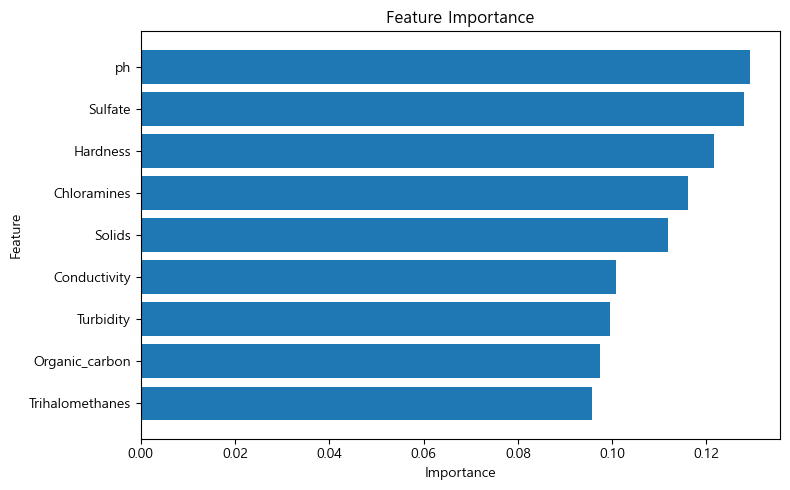

In [68]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['feature'],
    importance['importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

plt.tight_layout()
plt.show()

Feature importance 는 ph가 가장 높게 나왔으나 0.15 미만의 수치를 기록함 

- 본 데이터셋 중에서는 ph가 Potability를 결정하는데 가장 큰 영향을 끼치지만 그 수치는 0.15미만으로 Potability를 결정하는데 유의미하다고 보기 어려움 

In [ ]:
ph = float(input("ph ( 수소이온 농도 ) : "))
Hardness = float(input("Hardness ( 경도 ) : "))
Solids = float(input("Solids ( 총 용존 고형물 ): "))
Chloramines = float(input("Chloramines ( 클로라민 ): "))
Sulfate = float(input("Sulfate ( 황산염 ): "))
Conductivity = float(input("Conductivity ( 전기 전도도 ): "))
Organic_carbon = float(input("Organic_carbon ( 총 유기 탄소량 ) : "))
Trihalomethanes = float(input("Trihalomethanes ( 트리할로메탄 ) : "))
Turbidity = float(input("Turbidity ( 탁도 ) : "))

User_data = pd.DataFrame([
    [ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity]],
    columns = feature_names
)

pred = model.predict(User_data)
result = target_names[pred[0]]
print(f"결과는 {result} 입니다")